# 03 — Linear Regression

Progressive multiple linear regression predicting `log(TMB)` from clinical and genomic features.

**Models:**
1. `log_tmb ~ age`
2. `+ cancer_type`
3. `+ sex`
4. `+ msi_status`
5. `+ aneuploidy_score`
6. `+ fraction_genome_altered` (full additive)

**Interactions:** age × cancer_type, MSI × aneuploidy

**Residualization:** Regress out cancer type to reveal within-type predictor–TMB relationships

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats as sp_stats

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.plotting import set_style, save_fig, plot_coefficient_comparison, plot_residual_diagnostics
from src.stats import (
    fit_ols_formula, progressive_regression, compute_vif,
    extract_model_summary, partial_f_test,
)
from src.preprocessing import get_model_df

set_style()
FIGURES_DIR = PROJECT_ROOT / "figures"

df = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "tmb_merged.parquet")
print(f"Loaded {df.shape[0]} samples")

Loaded 10953 samples


## 1. Prepare Modeling Data

In [2]:
# Core predictors for the additive model
core_predictors = ["age_at_diagnosis", "cancer_type", "sex",
                   "aneuploidy_score", "fraction_genome_altered"]
available = [c for c in core_predictors if c in df.columns]

# Complete-case for core model
model_df = get_model_df(df, available, "log_tmb")
print(f"Complete cases (core): {len(model_df)}")

# Subset with MSI status
msi_predictors = available + ["msi_status"]
msi_available = [c for c in msi_predictors if c in df.columns]
msi_df = get_model_df(df, msi_available, "log_tmb")
print(f"Complete cases (with MSI): {len(msi_df)}")

Complete cases (core): 9568
Complete cases (with MSI): 9568


## 2. Progressive Regression

In [3]:
# Define predictor blocks to add sequentially
predictor_blocks = [
    ("M1: Age", "age_at_diagnosis"),
    ("M2: + Cancer Type", "C(cancer_type, Treatment(reference='Breast Invasive Carcinoma'))"),
    ("M3: + Sex", "C(sex)"),
    ("M4: + Aneuploidy", "aneuploidy_score"),
    ("M5: + FGA", "fraction_genome_altered"),
]

prog_summary = progressive_regression(model_df, "log_tmb", predictor_blocks)
print("\n=== Progressive Model Summary ===")
prog_summary.style.format({
    "adj_r2": "{:.4f}",
    "delta_adj_r2": "{:+.4f}",
    "aic": "{:.1f}",
    "bic": "{:.1f}",
    "f_pvalue": "{:.2e}",
})


=== Progressive Model Summary ===


,model,formula,n,adj_r2,delta_adj_r2,aic,bic,f_pvalue
0,M1: Age,log_tmb ~ age_at_diagnosis,9568,0.0650,+0.0650,25199.5,25213.8,nan


  Saved: progressive_r2.png, progressive_r2.pdf


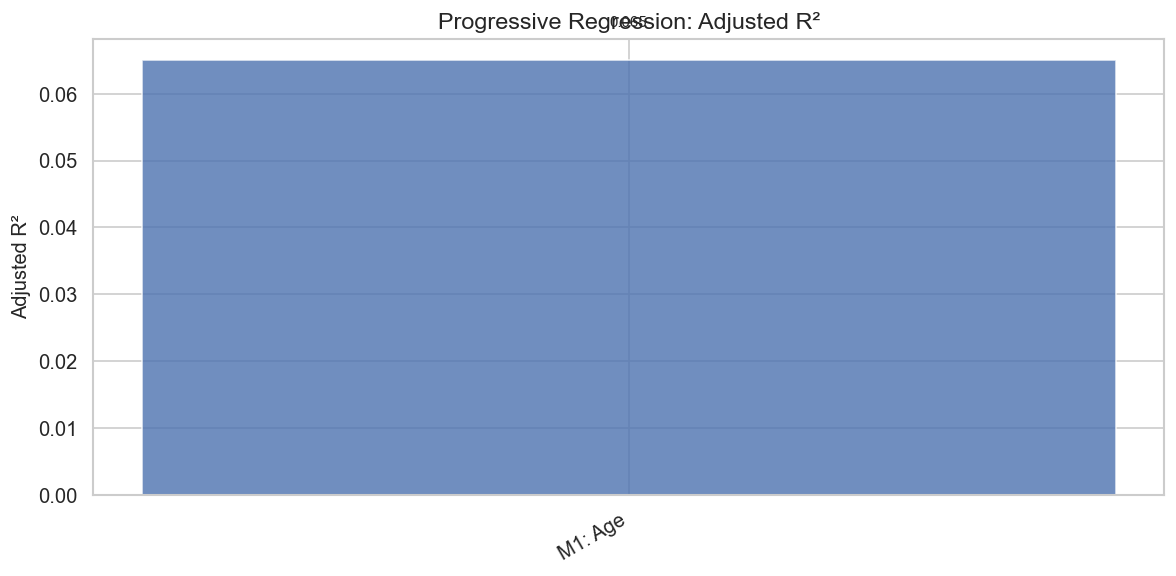

In [4]:
# Visualize adj R² progression
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(prog_summary)), prog_summary["adj_r2"], color="#4C72B0", alpha=0.8)
ax.set_xticks(range(len(prog_summary)))
ax.set_xticklabels(prog_summary["model"], rotation=30, ha="right")
ax.set_ylabel("Adjusted R²")
ax.set_title("Progressive Regression: Adjusted R²")
for i, v in enumerate(prog_summary["adj_r2"]):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
fig.tight_layout()
save_fig(fig, "progressive_r2", FIGURES_DIR)
plt.show()

## 3. Model 1: Simple Regression (Age Only)

In [5]:
m1 = fit_ols_formula(model_df, "log_tmb ~ age_at_diagnosis")
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                log_tmb   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     666.1
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          4.82e-142
Time:                        00:04:11   Log-Likelihood:                -12598.
No. Observations:                9568   AIC:                         2.520e+04
Df Residuals:                    9566   BIC:                         2.521e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.3522      0.039  

## 4. Full Additive Model

In [6]:
full_formula = "log_tmb ~ age_at_diagnosis + C(cancer_type) + C(sex) + aneuploidy_score + fraction_genome_altered"
m_full = fit_ols_formula(model_df, full_formula)
print(m_full.summary())

                            OLS Regression Results                            
Dep. Variable:                log_tmb   R-squared:                       0.447
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     234.0
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:04:11   Log-Likelihood:                -10082.
No. Observations:                9568   AIC:                         2.023e+04
Df Residuals:                    9534   BIC:                         2.048e+04
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [7]:
# Tidy coefficient table (excluding cancer type dummies for readability)
coef_df = extract_model_summary(m_full)
non_ct = coef_df[~coef_df["variable"].str.startswith("C(cancer_type")]
print("\nKey coefficients (full additive model):")
non_ct.style.format({
    "coef": "{:.4f}",
    "std_err": "{:.4f}",
    "t_stat": "{:.2f}",
    "p_value": "{:.2e}",
    "ci_lower": "{:.4f}",
    "ci_upper": "{:.4f}",
})


Key coefficients (full additive model):


,variable,coef,std_err,t_stat,p_value,ci_lower,ci_upper
0,Intercept,0.7125,0.0817,8.72,3.14e-18,0.5524,0.8726
30,C(sex)[T.MALE],0.0296,0.0177,1.67,9.42e-02,-0.0051,0.0643
31,age_at_diagnosis,0.0052,0.0006,9.02,2.29e-19,0.0040,0.0063
32,aneuploidy_score,-0.0036,0.0013,-2.80,5.08e-03,-0.0061,-0.0011
33,fraction_genome_altered,-0.0531,0.0475,-1.12,2.64e-01,-0.1463,0.0400


## 5. Full Model with MSI Status

In [8]:
if "msi_status" in msi_df.columns and msi_df["msi_status"].nunique() > 1:
    msi_formula = "log_tmb ~ age_at_diagnosis + C(cancer_type) + C(sex) + C(msi_status) + aneuploidy_score + fraction_genome_altered"
    m_msi = fit_ols_formula(msi_df, msi_formula)
    print(m_msi.summary())
    
    msi_coef = extract_model_summary(m_msi)
    non_ct_msi = msi_coef[~msi_coef["variable"].str.startswith("C(cancer_type")]
    print("\nKey coefficients (with MSI):")
    non_ct_msi.round(4)
else:
    print("MSI status not available or has insufficient variation — skipping.")

                            OLS Regression Results                            
Dep. Variable:                log_tmb   R-squared:                       0.550
Model:                            OLS   Adj. R-squared:                  0.548
Method:                 Least Squares   F-statistic:                     332.6
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:04:11   Log-Likelihood:                -8084.5
No. Observations:                9015   AIC:                         1.624e+04
Df Residuals:                    8981   BIC:                         1.648e+04
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------



Key coefficients (with MSI):


## 6. VIF Analysis

Variance Inflation Factors:
               variable      VIF
       age_at_diagnosis 1.022937
       aneuploidy_score 1.852036
fraction_genome_altered 1.825122


  Saved: vif_analysis.png, vif_analysis.pdf


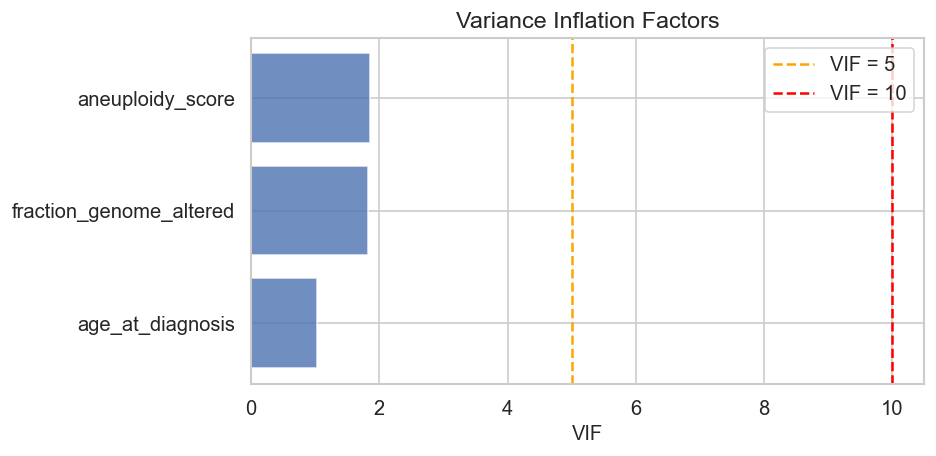


No multicollinearity concerns (all VIF < 5).


In [9]:
numeric_predictors = ["age_at_diagnosis", "aneuploidy_score", "fraction_genome_altered"]
avail_num = [c for c in numeric_predictors if c in model_df.columns]

if len(avail_num) >= 2:
    from src.plotting import plot_vif_bar
    vif_df = compute_vif(model_df, avail_num)
    print("Variance Inflation Factors:")
    print(vif_df.to_string(index=False))
    
    fig = plot_vif_bar(vif_df)
    save_fig(fig, "vif_analysis", FIGURES_DIR)
    plt.show()
    
    high_vif = vif_df[vif_df["VIF"] > 5]
    if len(high_vif) > 0:
        print(f"\nWarning: {len(high_vif)} variable(s) with VIF > 5:")
        print(high_vif.to_string(index=False))
    else:
        print("\nNo multicollinearity concerns (all VIF < 5).")

## 7. Interaction: Age × Cancer Type

In [10]:
# Test whether clock-like mutation accumulation rates vary by cancer type
int_formula_age = "log_tmb ~ age_at_diagnosis * C(cancer_type) + C(sex) + aneuploidy_score + fraction_genome_altered"
m_int_age = fit_ols_formula(model_df, int_formula_age)

# F-test: interaction model vs additive model
f_result = partial_f_test(m_full, m_int_age)
print(f"Age × Cancer Type interaction:")
print(f"  F-statistic: {f_result['f_stat']:.3f}")
print(f"  df: ({f_result['df_num']:.0f}, {f_result['df_denom']:.0f})")
print(f"  p-value: {f_result['p_value']:.2e}")
print(f"\n  Additive adj R²:     {m_full.rsquared_adj:.4f}")
print(f"  Interaction adj R²:  {m_int_age.rsquared_adj:.4f}")
print(f"  Delta adj R²:        {m_int_age.rsquared_adj - m_full.rsquared_adj:+.4f}")

Age × Cancer Type interaction:
  F-statistic: 8.044
  df: (29, 9505)
  p-value: 1.11e-16

  Additive adj R²:     0.4456
  Interaction adj R²:  0.4572
  Delta adj R²:        +0.0116


## 8. Interaction: MSI × Aneuploidy

In [11]:
if "msi_status" in msi_df.columns and msi_df["msi_status"].nunique() > 1:
    int_formula_msi = "log_tmb ~ age_at_diagnosis + C(cancer_type) + C(sex) + C(msi_status) * aneuploidy_score + fraction_genome_altered"
    m_int_msi = fit_ols_formula(msi_df, int_formula_msi)
    
    # Compare to additive MSI model
    f_msi = partial_f_test(m_msi, m_int_msi)
    print(f"MSI × Aneuploidy interaction:")
    print(f"  F-statistic: {f_msi['f_stat']:.3f}")
    print(f"  p-value: {f_msi['p_value']:.2e}")
    print(f"\n  Additive adj R²:     {m_msi.rsquared_adj:.4f}")
    print(f"  Interaction adj R²:  {m_int_msi.rsquared_adj:.4f}")
else:
    print("MSI data insufficient — skipping interaction.")

MSI × Aneuploidy interaction:
  F-statistic: 98.193
  p-value: 1.11e-16

  Additive adj R²:     0.5483
  Interaction adj R²:  0.5532


## 9. Regress Out Cancer Type

Extract residuals from `log_tmb ~ C(cancer_type)` and refit on remaining predictors to reveal within-type relationships.

In [12]:
# Step 1: Regress log_tmb on cancer type only
m_ct_only = fit_ols_formula(model_df, "log_tmb ~ C(cancer_type)")
print(f"Cancer-type-only model adj R²: {m_ct_only.rsquared_adj:.4f}")

# Step 2: Extract residuals
model_df_resid = model_df.copy()
model_df_resid["log_tmb_residual"] = m_ct_only.resid

# Step 3: Refit on remaining predictors
resid_formula = "log_tmb_residual ~ age_at_diagnosis + C(sex) + aneuploidy_score + fraction_genome_altered"
m_resid = fit_ols_formula(model_df_resid, resid_formula)
print(f"\nResidual model (within-type variation):")
print(m_resid.summary())

Cancer-type-only model adj R²: 0.4400

Residual model (within-type variation):
                            OLS Regression Results                            
Dep. Variable:       log_tmb_residual   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     19.33
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           7.41e-16
Time:                        00:04:11   Log-Likelihood:                -10093.
No. Observations:                9568   AIC:                         2.020e+04
Df Residuals:                    9563   BIC:                         2.023e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

In [13]:
# Compare coefficients: full model vs residualized model
resid_coef = extract_model_summary(m_resid)
full_coef = extract_model_summary(m_full)

# Filter to non-cancer-type variables
full_non_ct = full_coef[~full_coef["variable"].str.startswith("C(cancer_type")].copy()
resid_non_ct = resid_coef[~resid_coef["variable"].str.startswith("C(cancer_type")].copy()

print("Coefficient comparison (full vs residualized):")
comparison = full_non_ct[["variable", "coef"]].merge(
    resid_non_ct[["variable", "coef"]],
    on="variable",
    suffixes=("_full", "_resid"),
)
print(comparison.to_string(index=False))

Coefficient comparison (full vs residualized):
               variable  coef_full  coef_resid
              Intercept   0.712497   -0.203796
         C(sex)[T.MALE]   0.029631    0.012254
       age_at_diagnosis   0.005163    0.004023
       aneuploidy_score  -0.003564   -0.003231
fraction_genome_altered  -0.053139   -0.030998


## 10. Coefficient Forest Plot

  Saved: coefficient_forest_plot.png, coefficient_forest_plot.pdf


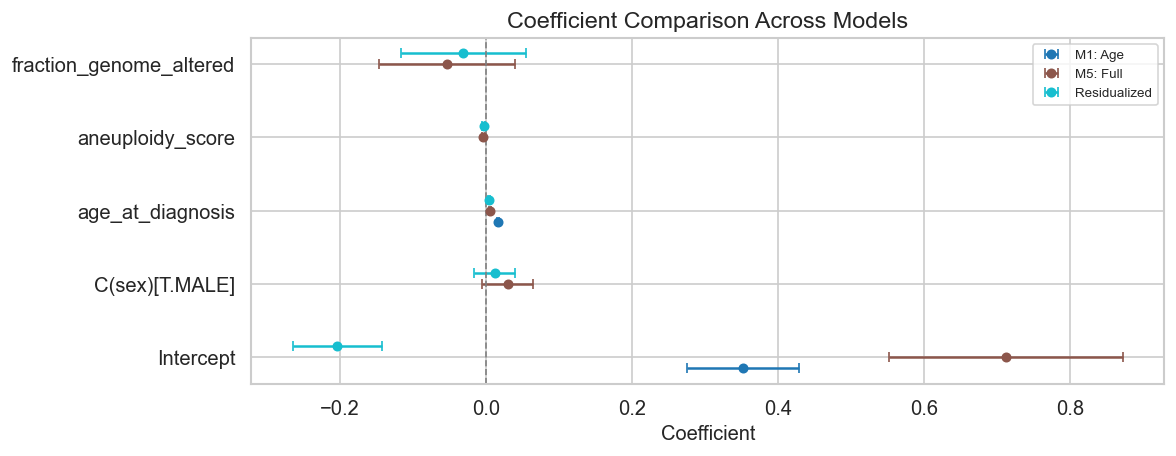

In [14]:
# Collect tidy summaries for key models
models_for_plot = {
    "M1: Age": extract_model_summary(m1),
    "M5: Full": extract_model_summary(m_full),
    "Residualized": extract_model_summary(m_resid),
}

fig = plot_coefficient_comparison(models_for_plot)
save_fig(fig, "coefficient_forest_plot", FIGURES_DIR)
plt.show()

## 11. Quick Residual Check (Full Model)

  Saved: residuals_full_model_quick.png, residuals_full_model_quick.pdf


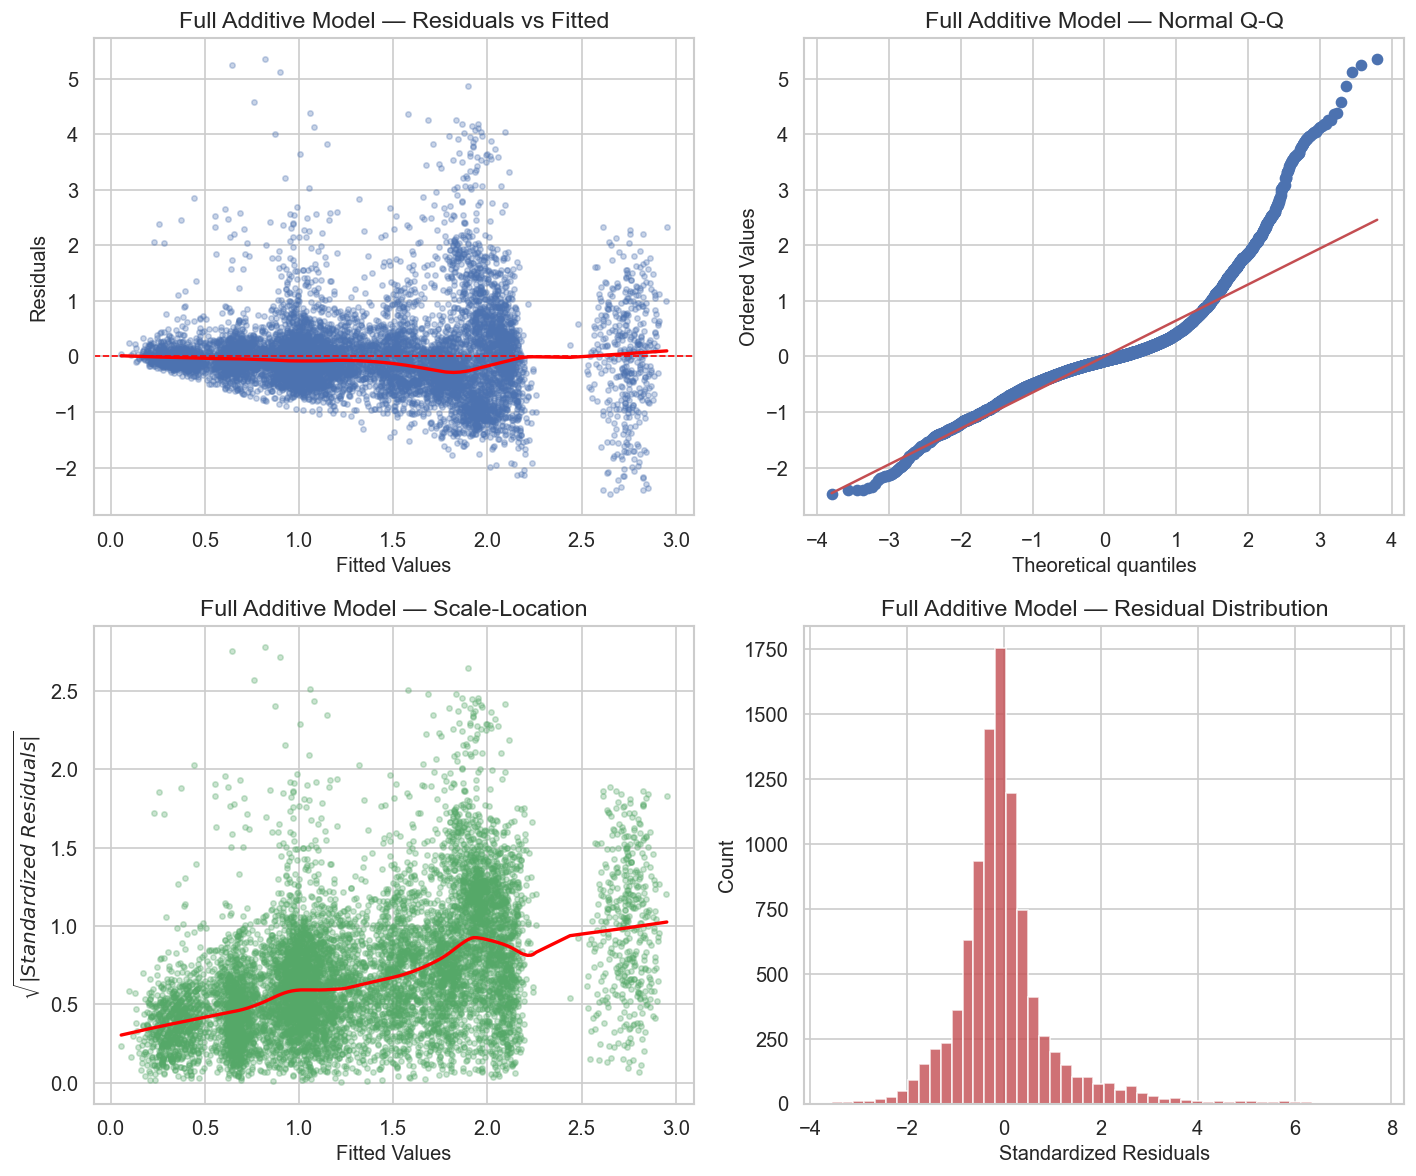

In [15]:
fig = plot_residual_diagnostics(
    m_full.fittedvalues.values,
    m_full.resid.values,
    model_name="Full Additive Model",
)
save_fig(fig, "residuals_full_model_quick", FIGURES_DIR)
plt.show()

## 12. Model Selection Discussion

**Key findings:**
- Adding cancer type causes the largest jump in adjusted R² — cancer type is the dominant predictor of TMB, consistent with known biology
- Age contributes modestly (clock-like mutations accumulate over time)
- MSI status (where available) is a strong predictor — MSI-H tumors have dramatically elevated TMB
- The age × cancer_type interaction tests whether mutation accumulation rates differ by tissue type
- After regressing out cancer type, residual predictors reveal within-type biological relationships

**Selected model for diagnostics (Notebook 05):**
The full additive model (`M5`) provides good interpretability. The interaction and residualized models provide additional biological insight.